# Quadrotor 2D sensor Koopman training and evaluation

This notebook runs a reference end-to-end experiment for sensor-based Koopman learning on `quadrotor_2d`.

It uses the same project code as the command-line entry points. The notebook is intended for inspection, diagnostics, and figure generation, not as a separate implementation of the training pipeline.

Expected runtime for full training: about 20 minutes.

## Workflow

1. Select the system, modality, dataset, and run identifier.
2. Optionally launch training.
3. Load the trained Koopman model.
4. Inspect the learned latent dynamics.
5. Run open-loop evaluation.
6. Optionally inspect closed-loop behavior.

In [36]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "KoNAMIC").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from KoNAMIC import config, paths, utils
from KoNAMIC.core.systems import create_system
from KoNAMIC.koopman.models import load_koop_model_for_eval
from KoNAMIC.koopman.models.model_config import ModelConfig
from KoNAMIC.pipelines.open_loop_simulation.run_config import load_open_loop_run_configs

%matplotlib inline

In [37]:
SYSTEM_NAME = "quadrotor_2d"
MODALITY = config.Modality.SENSOR
LATENT_DYNAMICS = "linear"
STATE_IN_Z = True  # True, False, or None to keep the YAML default.
RUN_DATASET_GENERATION = False
DATASET_CONTROLLER = "pid"
DATASET_STAMP = "2026-06-29_17-38-13_OK"
RUN_ID = "notebook_demo"
RUN_STATUS = "interim"
STAMP_RUN = None  # Example: "lin_notebook_demo_2026-07-05_14-30-00"
TRAINING_CONTROLLER_VARIANT = "position_in_z"
SEED = 0
EPOCH = None  # Set to an integer checkpoint epoch when needed.
OPEN_LOOP_PHASE = "val_2"
OPEN_LOOP_NUM_STEPS = 100
OPEN_LOOP_NUM_ROLLOUTS = 10

RUN_OPEN_LOOP_EVAL = True
RUN_CLOSED_LOOP_EVAL = True
CLOSED_LOOP_CONTROLLER = "kmpc"
CLOSED_LOOP_CONTROLLER_VARIANT = "position_in_z"
CLOSED_LOOP_SCENARIO_LEVEL = "aggressive"
RUN_TRAINING = True

In [38]:
utils.set_seed(SEED)

system_spec = create_system(SYSTEM_NAME)

print(f"project_root: {PROJECT_ROOT}")
print(f"system_name: {system_spec.system_name}")
print(f"x_dim: {system_spec.x_dim}")
print(f"u_dim: {system_spec.u_dim}")
print(f"modality: {MODALITY.key}")

project_root: /home/nicolas/Desktop/Projects/KoNAMIC_private
system_name: quadrotor_2d
x_dim: 6
u_dim: 2
modality: sensor


## Optional sensor dataset generation

Set `RUN_DATASET_GENERATION = True` to generate a fresh sensor dataset for `quadrotor_2d`.

The notebook delegates dataset generation to `entrypoints/generate_sensor_dataset.py`. After generation, update `DATASET_STAMP` with the timestamped dataset directory that was created.

In [39]:
if RUN_DATASET_GENERATION:
    import subprocess

    dataset_cmd = [
        sys.executable,
        str(PROJECT_ROOT / "entrypoints" / "generate_sensor_dataset.py"),
        "--system-name", SYSTEM_NAME,
        "--controller", DATASET_CONTROLLER,
        "--seed", str(SEED),
    ]

    print("Running:")
    print(" ".join(dataset_cmd))
    subprocess.run(dataset_cmd, cwd=PROJECT_ROOT, check=True)
else:
    print("Dataset generation skipped. Set RUN_DATASET_GENERATION = True to generate a dataset.")

Dataset generation skipped. Set RUN_DATASET_GENERATION = True to generate a dataset.


## Optional training

Set `RUN_TRAINING = True` to launch the standard training entry point from this notebook.

The notebook does not reimplement the training loop. It delegates training to `entrypoints/train_model.py`, then later cells can load and inspect the resulting run.

In [40]:
if RUN_TRAINING:
    import subprocess

    if STAMP_RUN is None:
        prefix_by_dynamics = {"linear": "lin", "bilinear": "bilin"}
        STAMP_RUN = f"{prefix_by_dynamics[LATENT_DYNAMICS]}_{RUN_ID}_{paths.make_timestamp()}"

    train_cmd = [
        sys.executable,
        str(PROJECT_ROOT / "entrypoints" / "train_model.py"),
        "--modality", MODALITY.key,
        "--system-name", SYSTEM_NAME,
        "--latent-dynamics", LATENT_DYNAMICS,
        "--dataset-stamp", DATASET_STAMP,
        "--id", RUN_ID,
        "--stamp-run", STAMP_RUN,
        "--seed", str(SEED),
    ]
    if TRAINING_CONTROLLER_VARIANT is not None:
        train_cmd.extend(["--controller-variant", TRAINING_CONTROLLER_VARIANT])
    if STATE_IN_Z is True:
        train_cmd.append("--state_in_z")
    elif STATE_IN_Z is False:
        train_cmd.append("--no-state_in_z")

    print("Running:")
    print(" ".join(train_cmd))
    subprocess.run(train_cmd, cwd=PROJECT_ROOT, check=True)

    run_paths = paths.build_run_paths(
        modality=MODALITY.key,
        system_name=SYSTEM_NAME,
        run_status=RUN_STATUS,
        stamp_run=STAMP_RUN,
    )
    print(f"STAMP_RUN: {STAMP_RUN}")
    print(f"Run directory: {run_paths.run_dir}")
else:
    print("Training skipped. Set RUN_TRAINING = True to launch training.")

Running:
/home/nicolas/miniconda3/envs/KoNAMIC/bin/python /home/nicolas/Desktop/Projects/KoNAMIC_private/entrypoints/train_model.py --modality sensor --system-name quadrotor_2d --latent-dynamics linear --dataset-stamp 2026-06-29_17-38-13_OK --id notebook_demo --stamp-run lin_notebook_demo_2026-07-05_13-49-00 --seed 0 --controller-variant position_in_z
Torch device: cuda
[DEBUG] is_jean_zay_env() = False
[DEBUG] SCRATCH = None
[DEBUG] dataset_root = /home/nicolas/Desktop/Projects/KoNAMIC_private/datasets/quadrotor_2d/2026-06-29_17-38-13_OK
[DEBUG] sensor_dir = /home/nicolas/Desktop/Projects/KoNAMIC_private/datasets/quadrotor_2d/2026-06-29_17-38-13_OK/sensor
[INFO] Loading train from /home/nicolas/Desktop/Projects/KoNAMIC_private/datasets/quadrotor_2d/2026-06-29_17-38-13_OK/sensor/train.npz
[INFO] Loading val_1 from /home/nicolas/Desktop/Projects/KoNAMIC_private/datasets/quadrotor_2d/2026-06-29_17-38-13_OK/sensor/val_1.npz
[INFO] Loading val_2 from /home/nicolas/Desktop/Projects/KoNAMIC_

100%|██████████| 4/4 [00:00<00:00, 30.42it/s]


Epoch: 0
train loss: 2.78e+00
	  reconstruction/01_y_rec :   2.35e-01
	  open_loop/01_y_pred     :   3.38e-01
	  open_loop/02_z_pred     :   9.58e-02
	  state rmse:
	  y           :   6.80e-02    theta       :   3.12e+00    z_dot       :   1.27e-01
	  z           :   5.42e-02    y_dot       :   1.22e-01    theta_dot   :   2.19e+01
val_1 loss: 5.16e-01
	  reconstruction/01_y_rec :   3.99e-02
	  open_loop/01_y_pred     :   8.37e-02
	  open_loop/02_z_pred     :   3.30e-02
	  state rmse:
	  y           :   3.83e-02    theta       :   1.70e+00    z_dot       :   6.98e-02
	  z           :   3.20e-02    y_dot       :   7.31e-02    theta_dot   :   7.00e+00
val_2 loss: 7.40e-01
	  reconstruction/01_y_rec :   4.28e-02
	  open_loop/01_y_pred     :   2.15e-01
	  open_loop/02_z_pred     :   9.73e-02
	  state rmse:
	  y           :   6.33e-02    theta       :   2.25e+00    z_dot       :   1.08e-01
	  z           :   4.88e-02    y_dot       :   1.41e-01    theta_dot   :   9.92e+00



  1%|▏         | 2/140 [00:00<00:07, 19.56it/s]

Epoch: 1
train loss: 3.20e-01
	  reconstruction/01_y_rec :   2.47e-02
	  open_loop/01_y_pred     :   5.38e-02
	  open_loop/02_z_pred     :   1.92e-02
	  state rmse:
	  y           :   3.08e-02    theta       :   1.32e+00    z_dot       :   5.60e-02
	  z           :   2.47e-02    y_dot       :   5.80e-02    theta_dot   :   5.98e+00
val_1 loss: 2.09e-01
	  reconstruction/01_y_rec :   1.57e-02
	  open_loop/01_y_pred     :   3.97e-02
	  open_loop/02_z_pred     :   1.22e-02
	  state rmse:
	  y           :   2.39e-02    theta       :   1.22e+00    z_dot       :   4.71e-02
	  z           :   1.99e-02    y_dot       :   5.26e-02    theta_dot   :   5.37e+00
val_2 loss: 3.48e-01
	  reconstruction/01_y_rec :   1.53e-02
	  open_loop/01_y_pred     :   1.57e-01
	  open_loop/02_z_pred     :   3.76e-02
	  state rmse:
	  y           :   5.48e-02    theta       :   2.08e+00    z_dot       :   8.36e-02
	  z           :   3.13e-02    y_dot       :   1.30e-01    theta_dot   :   8.02e+00



...

Epoch: 9
train loss: 3.34e-02
	  reconstruction/01_y_rec :   1.75e-03
	  open_loop/01_y_pred     :   1.38e-02
	  open_loop/02_z_pred     :   2.04e-03
	  state rmse:
	  y           :   1.05e-02    theta       :   6.33e-01    z_dot       :   3.14e-02
	  z           :   9.33e-03    y_dot       :   3.42e-02    theta_dot   :   3.25e+00
val_1 loss: 2.87e-02
	  reconstruction/01_y_rec :   1.26e-03
	  open_loop/01_y_pred     :   1.41e-02
	  open_loop/02_z_pred     :   1.92e-03
	  state rmse:
	  y           :   1.15e-02    theta       :   6.56e-01    z_dot       :   3.04e-02
	  z           :   8.79e-03    y_dot       :   3.51e-02    theta_dot   :   3.51e+00
val_2 loss: 9.11e-02
	  reconstruction/01_y_rec :   1.22e-03
	  open_loop/01_y_pred     :   7.20e-02
	  open_loop/02_z_pred     :   6.99e-03
	  state rmse:
	  y           :   3.35e-02    theta       :   1.46e+00    z_dot       :   6.11e-02
	  z           :   2.11e-02    y_dot       :   8.81e-02    theta_dot   :   4.09e+00



100%|██████████| 4/4 [00:00<00:00, 31.23it/s]


Epoch: 10
train loss: 3.29e-02
	  reconstruction/01_y_rec :   1.72e-03
	  open_loop/01_y_pred     :   1.38e-02
	  open_loop/02_z_pred     :   1.90e-03
	  state rmse:
	  y           :   1.04e-02    theta       :   6.39e-01    z_dot       :   3.10e-02
	  z           :   9.27e-03    y_dot       :   3.45e-02    theta_dot   :   3.22e+00
val_1 loss: 3.33e-02
	  reconstruction/01_y_rec :   1.83e-03
	  open_loop/01_y_pred     :   1.31e-02
	  open_loop/02_z_pred     :   1.86e-03
	  state rmse:
	  y           :   1.02e-02    theta       :   6.34e-01    z_dot       :   2.98e-02
	  z           :   8.03e-03    y_dot       :   3.33e-02    theta_dot   :   3.69e+00
val_2 loss: 9.04e-02
	  reconstruction/01_y_rec :   1.82e-03
	  open_loop/01_y_pred     :   6.56e-02
	  open_loop/02_z_pred     :   6.65e-03
	  state rmse:
	  y           :   2.82e-02    theta       :   1.47e+00    z_dot       :   6.15e-02
	  z           :   1.96e-02    y_dot       :   8.10e-02    theta_dot   :   4.51e+00



 99%|█████████▊| 138/140 [00:07<00:00, 18.84it/s]

KeyboardInterrupt: 

## Select a trained run

Set `STAMP_RUN` to the timestamped run directory to inspect.

If `RUN_TRAINING = True`, use the run directory created by the training command. Otherwise, select an existing run from `outputs/`.

In [41]:
runs_base_dir = paths.build_base_output_dir(
    modality=MODALITY.key,
    run_status=RUN_STATUS,
    system_name=SYSTEM_NAME,
)
runs_dir = runs_base_dir / "runs"

print(f"runs_dir: {runs_dir}")

if STAMP_RUN is None:
    print("Set STAMP_RUN to one of the available run directories before loading a model.")
    if runs_dir.exists():
        run_dirs = sorted(
            [p for p in runs_dir.iterdir() if p.is_dir()],
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )
        print("\nMost recent runs:")
        for run_path in run_dirs[:10]:
            print(f"- {run_path.name}")
    else:
        print("No runs directory found yet.")
    run_paths = None
else:
    run_paths = paths.build_run_paths(
        modality=MODALITY.key,
        system_name=SYSTEM_NAME,
        run_status=RUN_STATUS,
        stamp_run=STAMP_RUN,
    )
    if not run_paths.run_dir.exists():
        raise FileNotFoundError(f"Run directory does not exist: {run_paths.run_dir}")
    print(f"Selected run directory: {run_paths.run_dir}")

runs_dir: /home/nicolas/Desktop/Projects/KoNAMIC_private/outputs/interim/sensor/quadrotor_2d/runs
Selected run directory: /home/nicolas/Desktop/Projects/KoNAMIC_private/outputs/interim/sensor/quadrotor_2d/runs/lin_notebook_demo_2026-07-05_13-49-00


## Load the trained model

This cell loads the saved run configuration, resolves model dimensions from the selected system, selects a checkpoint epoch, and loads the trained Koopman model with its dataset scalers.

In [42]:
if run_paths is None:
    raise RuntimeError("Set STAMP_RUN and rerun the run-selection cell before loading a model.")

model_config, data_preparation_config = load_open_loop_run_configs(
    run_paths=run_paths,
    system_spec=system_spec,
)

if EPOCH is None:
    checkpoint_paths = sorted(run_paths.checkpoints_dir.glob("model_epoch_*.pt"))
    if not checkpoint_paths:
        raise FileNotFoundError(f"No checkpoints found in {run_paths.checkpoints_dir}")
    epoch = max(int(path.stem.rsplit("_", 1)[-1]) for path in checkpoint_paths)
else:
    epoch = int(EPOCH)

koop_model, data_scalers = load_koop_model_for_eval(
    MODALITY,
    model_config,
    epoch,
    run_paths.run_dir,
)

print(f"Loaded epoch: {epoch}")
print(f"model type: {type(koop_model).__name__}")
print(f"x_dim: {model_config.z_dynamics.x_dim}")
print(f"u_dim: {model_config.z_dynamics.u_dim}")
print(f"z_dim: {model_config.z_dynamics.z_dim}")
print(f"latent dynamics: {model_config.z_dynamics.model}")
print(f"include_state_in_z: {model_config.auto_encoder.include_state_in_z}")

Torch device: cuda
Loaded epoch: 10
model type: SensorKoopModel
x_dim: 6
u_dim: 2
z_dim: 12
latent dynamics: linear
include_state_in_z: False


## Inspect Koopman matrices

Extract the learned latent dynamics matrices and inspect their dimensions, norms, and eigenvalues.

A shape: (12, 12)
B shape: (12, 2)
||A||_F: 3.4627
||B||_F: 0.0458
max |eig(A)|: 1.0177


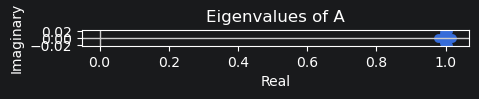

In [43]:
with torch.no_grad():
    A_t, B_t = koop_model.construct_koop_matrices()

A = A_t.detach().cpu().numpy()
B = B_t.detach().cpu().numpy()
eigvals = np.linalg.eigvals(A)

print(f"A shape: {A.shape}")
print(f"B shape: {B.shape}")
print(f"||A||_F: {np.linalg.norm(A):.4f}")
print(f"||B||_F: {np.linalg.norm(B):.4f}")
print(f"max |eig(A)|: {np.max(np.abs(eigvals)):.4f}")

fig, ax = plt.subplots(figsize=(5, 5))
unit_circle = plt.Circle((0.0, 0.0), 1.0, color="black", fill=False, linestyle="--", linewidth=1)
ax.add_artist(unit_circle)
ax.scatter(eigvals.real, eigvals.imag, s=28)
ax.axhline(0.0, color="0.8", linewidth=1)
ax.axvline(0.0, color="0.8", linewidth=1)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Real")
ax.set_ylabel("Imaginary")
ax.set_title("Eigenvalues of A")
plt.show()

## Optional open-loop evaluation

Set `RUN_OPEN_LOOP_EVAL = True` to launch the standard open-loop evaluation entry point from this notebook.

The notebook delegates rollout generation and rendering to `entrypoints/run_open_loop_simulation.py`.

Generated figures and rollout artifacts are saved under the selected run directory, in `eval/standalone/open_loop/<eval_timestamp>/`.

In [45]:
if RUN_OPEN_LOOP_EVAL:
    if STAMP_RUN is None:
        raise RuntimeError("Set STAMP_RUN before launching open-loop evaluation.")
    if DATASET_STAMP == "TODO_DATASET_STAMP":
        raise RuntimeError("Set DATASET_STAMP before launching open-loop evaluation.")

    import subprocess

    open_loop_cmd = [
        sys.executable,
        str(PROJECT_ROOT / "entrypoints" / "run_open_loop_simulation.py"),
        "--modality", MODALITY.key,
        "--system-name", SYSTEM_NAME,
        "--dataset-stamp", DATASET_STAMP,
        "--stamp-run", STAMP_RUN,
        "--run-status", RUN_STATUS,
        "--phase", OPEN_LOOP_PHASE,
        "--num-steps", str(OPEN_LOOP_NUM_STEPS),
        "--num-rollouts", str(OPEN_LOOP_NUM_ROLLOUTS),
        "--epoch", str(epoch),
        "--seed", str(SEED),
    ]

    print("Running:")
    print(" ".join(open_loop_cmd))
    subprocess.run(open_loop_cmd, cwd=PROJECT_ROOT, check=True)
else:
    print("Open-loop evaluation skipped. Set RUN_OPEN_LOOP_EVAL = True to launch it.")

Running:
/home/nicolas/miniconda3/envs/KoNAMIC/bin/python /home/nicolas/Desktop/Projects/KoNAMIC_private/entrypoints/run_open_loop_simulation.py --modality sensor --system-name quadrotor_2d --dataset-stamp 2026-06-29_17-38-13_OK --stamp-run lin_notebook_demo_2026-07-05_13-49-00 --run-status interim --phase val_1 --num-steps 50 --num-rollouts 1 --epoch 10 --seed 0
2026-07-05 13:52:04 [INFO] KoNAMIC.utils.logging: Time stamp: 2026-07-05_13-52-04
Torch device: cuda
[DEBUG] is_jean_zay_env() = False
[DEBUG] SCRATCH = None
[DEBUG] dataset_root = /home/nicolas/Desktop/Projects/KoNAMIC_private/datasets/quadrotor_2d/2026-06-29_17-38-13_OK
[DEBUG] sensor_dir = /home/nicolas/Desktop/Projects/KoNAMIC_private/datasets/quadrotor_2d/2026-06-29_17-38-13_OK/sensor
[INFO] Loading train from /home/nicolas/Desktop/Projects/KoNAMIC_private/datasets/quadrotor_2d/2026-06-29_17-38-13_OK/sensor/train.npz
[INFO] Loading val_1 from /home/nicolas/Desktop/Projects/KoNAMIC_private/datasets/quadrotor_2d/2026-06-29_

## Optional closed-loop evaluation

Set `RUN_CLOSED_LOOP_EVAL = True` to launch the standard closed-loop simulation entry point.

This cell runs KMPC with `--controller kmpc` and `--controller-variant position_in_z`. Generated trajectories, metrics, solver logs, and figures are saved under the closed-loop evaluation output directory.

In [51]:
if RUN_CLOSED_LOOP_EVAL:
    if STAMP_RUN is None:
        raise RuntimeError("Set STAMP_RUN before launching closed-loop evaluation.")

    import subprocess

    closed_loop_cmd = [
        sys.executable,
        str(PROJECT_ROOT / "entrypoints" / "run_closed_loop_simulation.py"),
        "--modality", MODALITY.key,
        "--system-name", SYSTEM_NAME,
        "--scenario-level", CLOSED_LOOP_SCENARIO_LEVEL,
        "--stamp-run", STAMP_RUN,
        "--controller", CLOSED_LOOP_CONTROLLER,
        "--run-status", RUN_STATUS,
        "--controller-variant", CLOSED_LOOP_CONTROLLER_VARIANT,
        "--epoch", str(epoch),
        "--seed", str(SEED),
    ]

    print("Running:")
    print(" ".join(closed_loop_cmd))
    subprocess.run(closed_loop_cmd, cwd=PROJECT_ROOT, check=True)
else:
    print("Closed-loop evaluation skipped. Set RUN_CLOSED_LOOP_EVAL = True to launch it.")

Running:
/home/nicolas/miniconda3/envs/KoNAMIC/bin/python /home/nicolas/Desktop/Projects/KoNAMIC_private/entrypoints/run_closed_loop_simulation.py --modality sensor --system-name quadrotor_2d --scenario-level aggressive --stamp-run lin_notebook_demo_2026-07-05_13-49-00 --controller kmpc --run-status interim --controller-variant structured_latent --epoch 10 --seed 0
2026-07-05 13:56:39 [INFO] KoNAMIC.utils.logging: Time stamp: 2026-07-05_13-56-39
Torch device: cuda
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to a

  0%|          | 0/100 [00:00<?, ?it/s]

Error on x: 4.14e-03, Error on z: 2.73e-03, term err: 1.14e-02, SQP: 1.0, OS: (0.0%, 0.0%), Ts: (0.00s, 0.00s), ✅ OK

Simulation 2/5
Error on x: 1.25e-01, Error on z: 1.26e-01, term err: 3.62e-01, SQP: 1.0, OS: (0.0%, 0.0%), Ts: (0.00s, 0.00s), ✅ OK

Simulation 3/5


  0%|          | 0/100 [00:00<?, ?it/s]

Error on x: 6.51e-02, Error on z: 4.05e-02, term err: 9.21e-02, SQP: 1.0, OS: (0.0%, 0.0%), Ts: (0.00s, 0.00s), ✅ OK

Simulation 4/5
Error on x: 9.52e-02, Error on z: 6.31e-02, term err: 1.67e-01, SQP: 1.0, OS: (0.0%, 0.0%), Ts: (0.00s, 0.00s), ✅ OK

Simulation 5/5


100%|██████████| 100/100 [00:00<00:00, 605.54it/s]


Error on x: 1.14e-01, Error on z: 7.11e-02, term err: 2.04e-01, SQP: 1.0, OS: (0.0%, 0.0%), Ts: (0.00s, 0.00s), ✅ OK
📊 Performance Metrics
──────────────────────────────────────────────────────────────────────
  Total simulations:     5
  Successful:            5 (100.0%)
  Diverged:              0

📈 Mean errors on Physical State (x, y positions)
──────────────────────────────────────────────────────────────────────
  Mean:      8.0735e-02
  Std:       4.3363e-02

📈 Error on Latent State (z)
──────────────────────────────────────────────────────────────────────
  Mean:      6.0734e-02
  Std:       4.0434e-02

🎯 Terminal Error (L2 norm at final step) [m]
──────────────────────────────────────────────────────────────────────
  Mean:      1.6719e-01
  Std:       1.1750e-01

⚙️  Mean SQP iterations
──────────────────────────────────────────────────────────────────────
  Mean:      1.0000e+00
  Std:       0.0000e+00

📌 Overshoot (%) — coordonnées 1 et 2
────────────────────────────────────